### Visualize the similarity between DEGs within each of the contrasts

In [3]:
library(tidyverse)
library(reshape2)

In [4]:
plots_dir <- "DESeq2_plots/"
dir.create(plots_dir)

In [5]:
contrasts <- c("disease")
num_contrasts <- length(contrasts)

corresponding_contrast_file_names <- c("disease_binary_Y_vs_N")

cell_types <- c("Adipocyte", "Cardiomyocyte", "Endocardial", "Endothelial", "Epicardial",
              "Fibroblast", "Lymphoid", "LEC", "Mast", "Myeloid", "Neuronal", "Pericyte", "vSMC")

q_val_threshold <- 0.05
log2_FC_threshold <- 0.5

In [6]:
extract_up_and_down_genes <- function(DE_genes_df, q_val_threshold, log2_FC_threshold) {
    # obtain the number of DE genes that are up and down regulated
    up_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange >= log2_FC_threshold)
    down_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange <= -log2_FC_threshold)   

    up_sig_genes <- dim(up_df)[1]
    down_sig_genes <- dim(down_df)[1]

    return(list(up_sig_genes, down_sig_genes))
}

### Iterate through all cell types and create a df with all of the DEG genes

In [7]:
up_list <- list()
down_list <- list()

for (cell_type in cell_types) {

    for (i in 1:num_contrasts) {
        contrast_val <- contrasts[i]
        contrast_file_name <- corresponding_contrast_file_names[i]
        contrast_file_path <- paste0("pydeseq2_results/", cell_type, "_", contrast_file_name, "_results.csv")

        if (file.exists(contrast_file_path)) {
            df <- read.csv(contrast_file_path, row.names = 1)
            # add additional columns
            df$cell_type <- cell_type
            df$contrast <- contrast_val

            # create separate dfs for up and down DEGs
            up_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange >= log2_FC_threshold)
            down_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange <= -log2_FC_threshold)

            up_list[[length(up_list) + 1]] <- up_df
            down_list[[length(down_list) + 1]] <- down_df
        }
    }
}

# combine all up and down genes
up_DEGs_combined_df <- bind_rows(up_list)
down_DEGs_combined_df <- bind_rows(down_list)

In [12]:
dim(up_DEGs_combined_df)
dim(down_DEGs_combined_df)

[1] 7821   11

[1] 9516   11

#### Compute the Jaccard similarity of DEGs for the same contrast, across all cell types. Do this for all 4 contrasts.

In [9]:
jaccard_similarity <- function(set1, set2) {
  length(intersect(set1, set2)) / length(union(set1, set2))
}

In [13]:
# function to compute the Jaccard similarity for all DEGs across cell types in DEG_df, for the specific contrast
compute_jaccard_similarity_for_contrast <- function(contrast_of_interest, DEG_df) {
    
    # filter the df to contrast of interest
    filtered_df <- DEG_df %>%
  filter(contrast == contrast_of_interest)

    # group the DEGs by cell type and store as a list of sets of DEGs
    cell_type_gene_list <- filtered_df %>%
    group_by(cell_type) %>%
    summarize(genes = list(gene_id)) %>%
    pull(genes) %>%
    setNames(filtered_df$cell_type %>% unique())

    # iterate through all cell type comparisons
    cell_types <- names(cell_type_gene_list)

    # create matrix to store the Jaccard similarity
    jaccard_matrix <- matrix(0, nrow = length(cell_types), ncol = length(cell_types),
                         dimnames = list(cell_types, cell_types))
    # iterate through all cell types
    for (i in seq_along(cell_types)) {
        for (j in seq_along(cell_types)) {
    jaccard_matrix[i, j] <- jaccard_similarity(cell_type_gene_list[[i]], cell_type_gene_list[[j]])
        }
    }

    # convert the matrix 
    jaccard_df <- melt(jaccard_matrix) %>%
        rename(cell_type_1 = Var1, cell_type_2 = Var2, similarity = value)

    # produce plot
    p1 <- ggplot(jaccard_df, aes(x = cell_type_1, y = cell_type_2, fill = similarity)) +
      geom_tile(color = "white") +
      scale_fill_gradient(low = "white", high = "blue", name = "Jaccard\nSimilarity") +
      theme_minimal() +
      theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 12),
            axis.text.y = element_text(size = 12),
        axis.title.x = element_blank(),
        axis.title.y = element_blank()) +
      labs(title = paste("Jaccard Similarity for", contrast_of_interest))

    # return the Jaccard similarity matrix and plot

    return(list(jaccard_matrix, p1))
}

### Produce jaccard plots for up DEGs

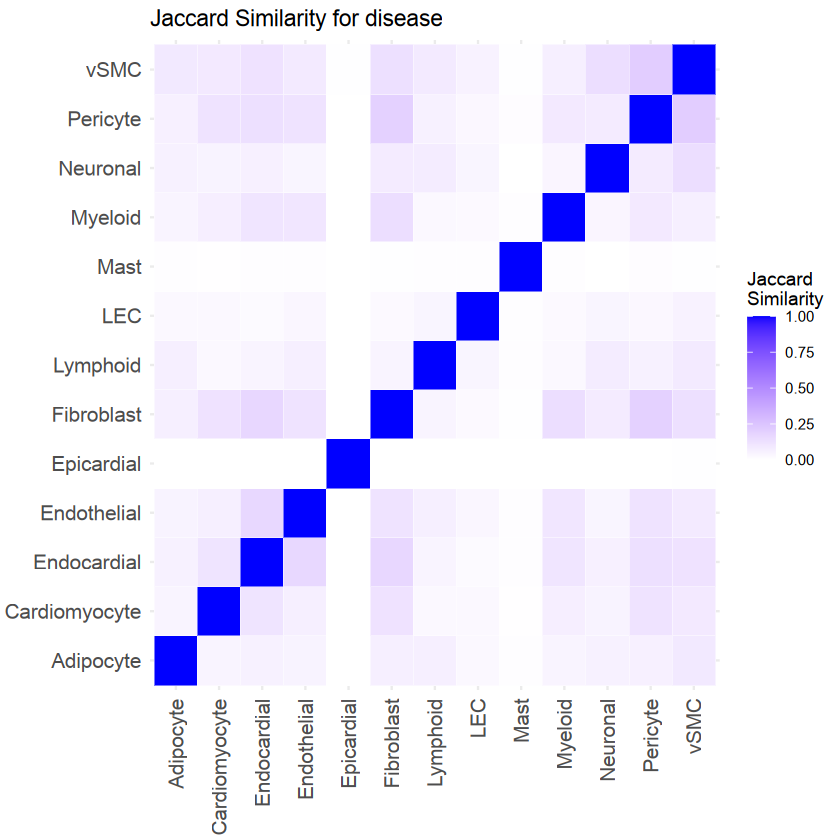

In [14]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "disease", DEG_df = up_DEGs_combined_df)
results[[2]]

### Compute Jaccard similarity for down DEGs

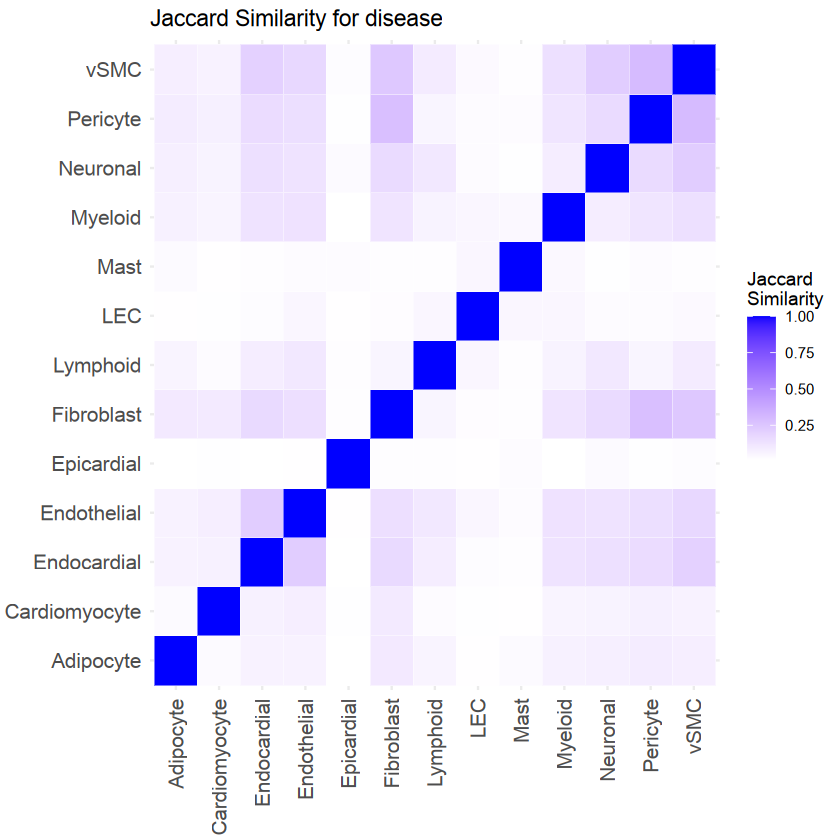

In [15]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "disease", DEG_df = down_DEGs_combined_df)
results[[2]]

### Another analysis is to identify which genes are consistently DEG across cell types

In [16]:
get_common_DEGs_across_cell_types <- function(contrast_of_interest, DEG_df) {

    # filter the df to contrast of interest
    filtered_df <- DEG_df %>% filter(contrast == contrast_of_interest)

    # group the DEGs by cell type and store as a list of sets of DEGs
    cell_type_gene_list <- filtered_df %>%
    group_by(cell_type) %>%
    summarize(genes = list(gene_id)) %>%
    pull(genes) %>%
    setNames(filtered_df$cell_type %>% unique())

    # convert list to df
    genes_across_cell_types <- cell_type_gene_list %>%
    enframe(name = "cell_type", value = "genes") %>% 
    unnest(cols = c(genes)) 

    # return the number of cell types for which that gene is a DEG
    gene_cell_type_counts <- genes_across_cell_types %>%
    group_by(genes) %>%
    summarize(num_cell_types = n(), cell_types = paste(unique(cell_type), collapse = ", ")) %>%
    arrange(desc(num_cell_types))

    # save this as a histogram too
    p2 <- ggplot(data = gene_cell_type_counts, mapping = aes(x = num_cell_types)) + geom_histogram() + theme_bw() +
    theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16),
         axis.text.y = element_text(size = 16),
	 strip.text = element_text(size = 18))
    
    return(list(gene_cell_type_counts, p2))

}

#### Perform for up DEGs

[1] "disease"
# A tibble: 4,442 × 5
   genes       num_cell_types cell_types                      contrast direction
   <chr>                <int> <chr>                           <chr>    <chr>    
 1 TENM4                   10 Cardiomyocyte, Endocardial, En… disease  up       
 2 XAF1                    10 Adipocyte, Cardiomyocyte, Endo… disease  up       
 3 FGF14                    9 Adipocyte, Endocardial, Endoth… disease  up       
 4 HBA2                     9 Adipocyte, Cardiomyocyte, Endo… disease  up       
 5 LTBP2                    9 Adipocyte, Endocardial, Endoth… disease  up       
 6 NPPA                     9 Cardiomyocyte, Endocardial, En… disease  up       
 7 ADAMTS9-AS2              8 Adipocyte, Endocardial, Endoth… disease  up       
 8 AFF3                     8 Endocardial, Endothelial, Fibr… disease  up       
 9 BICC1                    8 Adipocyte, Cardiomyocyte, Endo… disease  up       
10 FAM66C                   8 Cardiomyocyte, Endocardial, En… disease  up

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


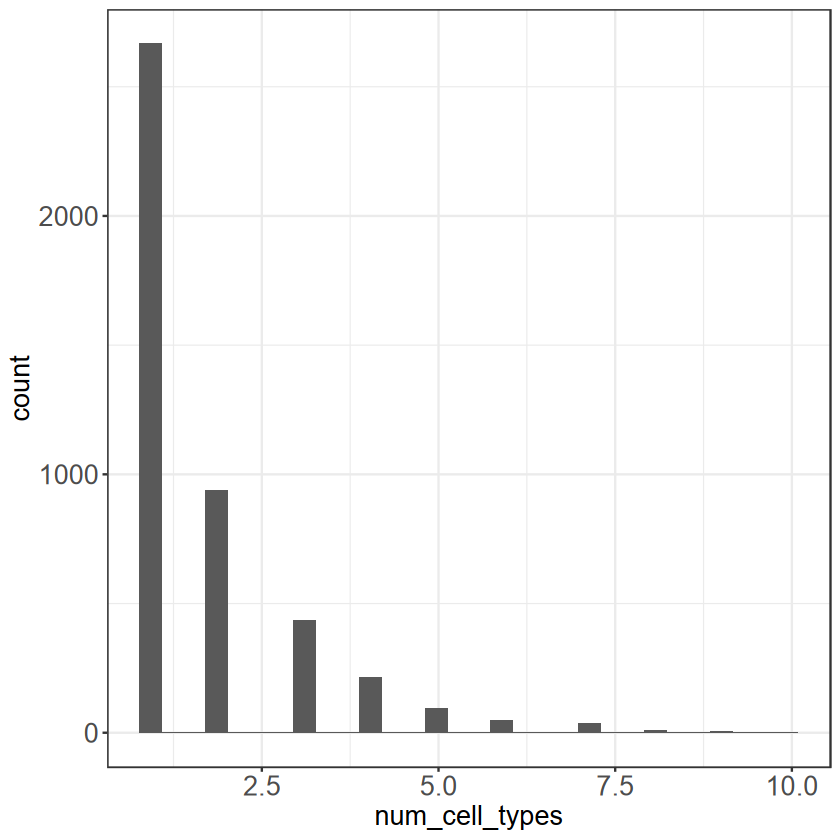

In [17]:
up_DEGs_results_list <- list() 

for (contrast in contrasts) {
    print(contrast)
    
    results <- get_common_DEGs_across_cell_types(contrast_of_interest = contrast, DEG_df = up_DEGs_combined_df)
    results_df <- results[[1]]
    results_df$contrast <- contrast
    results_df$direction <- "up"
    
    up_DEGs_results_list[[contrast]] <- results_df
    print(results_df)
    print(results[[2]])
    flush.console()
}

In [19]:
up_DEGs_results_list$disease %>% head(20)

genes,num_cell_types,cell_types,contrast,direction
<chr>,<int>,<chr>,<chr>,<chr>
TENM4,10,"Cardiomyocyte, Endocardial, Endothelial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",disease,up
XAF1,10,"Adipocyte, Cardiomyocyte, Endothelial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",disease,up
FGF14,9,"Adipocyte, Endocardial, Endothelial, Fibroblast, Lymphoid, Myeloid, Neuronal, Pericyte, vSMC",disease,up
HBA2,9,"Adipocyte, Cardiomyocyte, Endocardial, Endothelial, Fibroblast, LEC, Myeloid, Pericyte, vSMC",disease,up
LTBP2,9,"Adipocyte, Endocardial, Endothelial, Fibroblast, Lymphoid, Myeloid, Neuronal, Pericyte, vSMC",disease,up
NPPA,9,"Cardiomyocyte, Endocardial, Endothelial, Fibroblast, LEC, Myeloid, Neuronal, Pericyte, vSMC",disease,up
ADAMTS9-AS2,8,"Adipocyte, Endocardial, Endothelial, Fibroblast, LEC, Myeloid, Pericyte, vSMC",disease,up
AFF3,8,"Endocardial, Endothelial, Fibroblast, Lymphoid, LEC, Mast, Myeloid, Pericyte",disease,up
BICC1,8,"Adipocyte, Cardiomyocyte, Endocardial, Endothelial, LEC, Myeloid, Pericyte, vSMC",disease,up


### Perform for down DEGs

[1] "disease"
# A tibble: 4,999 × 5
   genes  num_cell_types cell_types                           contrast direction
   <chr>           <int> <chr>                                <chr>    <chr>    
 1 MYH6               12 Adipocyte, Cardiomyocyte, Endocardi… disease  down     
 2 TXNRD1             11 Adipocyte, Endocardial, Endothelial… disease  down     
 3 IFITM3             10 Cardiomyocyte, Endocardial, Endothe… disease  down     
 4 S100A4             10 Adipocyte, Cardiomyocyte, Endocardi… disease  down     
 5 S100A6             10 Endocardial, Endothelial, Epicardia… disease  down     
 6 APOD                9 Cardiomyocyte, Endocardial, Endothe… disease  down     
 7 C1R                 9 Cardiomyocyte, Endocardial, Endothe… disease  down     
 8 CD63                9 Endocardial, Endothelial, Fibroblas… disease  down     
 9 HSPA5               9 Adipocyte, Endocardial, Endothelial… disease  down     
10 NEAT1               9 Adipocyte, Endocardial, Endothelial… disease  do

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


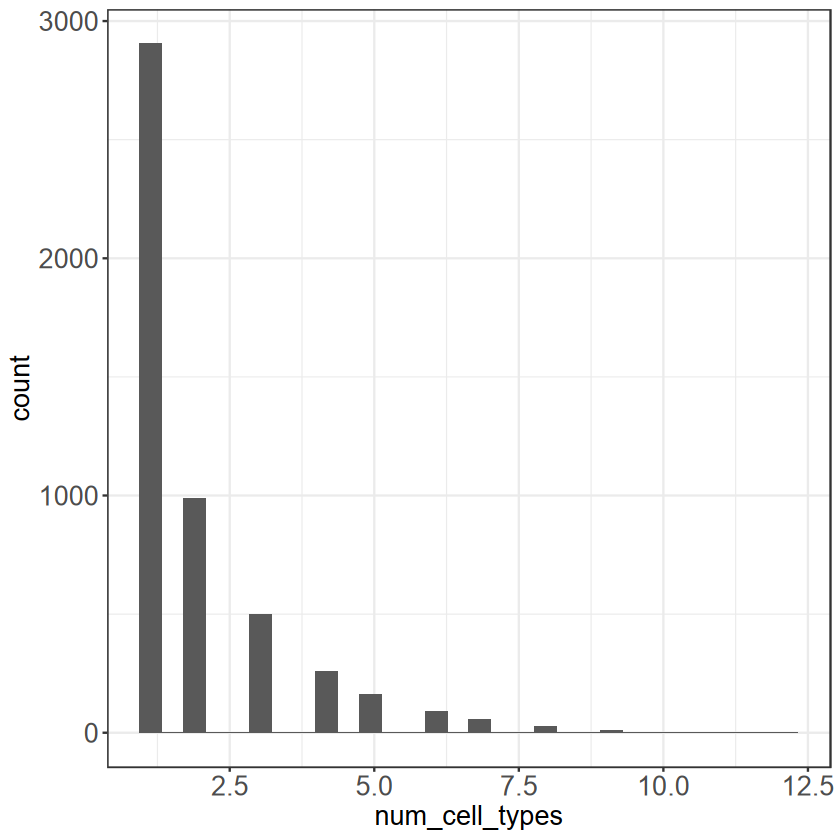

In [20]:
down_DEGs_results_list <- list()

for (contrast in contrasts) {
    print(contrast)
    
    results <- get_common_DEGs_across_cell_types(contrast_of_interest = contrast, DEG_df = down_DEGs_combined_df)
    results_df <- results[[1]]
    results_df$contrast <- contrast
    results_df$direction <- "down"
    
    down_DEGs_results_list[[contrast]] <- results_df
    print(results_df)
    print(results[[2]])
    flush.console()
}

In [23]:
down_genes <- down_DEGs_results_list$disease

In [24]:
down_genes$genes %>% head(100)

[1] "MYH6"      "TXNRD1"    "IFITM3"    "S100A4"    "S100A6"    "APOD"     
  [7] "C1R"       "CD63"      "HSPA5"     "NEAT1"     "NNMT"      "PLA2G2A"  
 [13] "S100A11"   "TIMP1"     "TXNIP"     "ADH1B"     "C14orf119" "CALR"     
 [19] "CFD"       "CFL2"      "CKM"       "CLIC1"     "COX5A"     "CRYAB"    
 [25] "DSP"       "HIF3A"     "HSP90B1"   "IGFBP6"    "LINC00482" "LINC00881"
 [31] "PGAM2"     "PLA2G5"    "PPIB"      "PRDX1"     "RARRES1"   "RBMS3-AS2"
 [37] "S100A10"   "SLC16A7"   "SLC25A4"   "SREBF1"    "TPI1"      "TUBB4B"   
 [43] "ADAMTS4"   "ADAMTSL4"  "ARL6IP5"   "ATP1B1"    "ATP1B3"    "BCL3"     
 [49] "BSG"       "BZW2"      "C1QC"      "CCL2"      "CD151"     "CD81"     
 [55] "CNBP"      "COX5B"     "COX6A1"    "CST3"      "CYC1"      "ENO1"     
 [61] "FHL2"      "FTH1"      "G0S2"      "GABARAPL1" "GAPDH"     "GBE1"     
 [67] "GGT5"      "HIPK2"     "IFITM2"    "IGFBP4"    "JAGN1"     "MFGE8"    
 [73] "MGST1"     "MID1IP1"   "MT-ND6"    "MT1M"      "NDUFB4"    "PCBP1"    
 [79] "PGAM1"     "PTP4A3"    "RNASE1"    "RPL22L1"   "RPLP0"     "RPSA"     
 [85] "SBDS"      "SH3BGRL3"  "SLC25A3"   "SLC52A2"   "SNHG7"     "SNHG8"    
 [91] "STEAP4"    "TAGLN2"    "TM4SF1"    "TMBIM1"    "TMED9"     "TSPO"     
 [97] "UBC"       "UQCRFS1"   "XPR1"      "A4GALT"

In [26]:
#down_genes[down_genes$genes == "THRB", ]

### Produce plots for number of cell types sharing the same DEGs

In [29]:
combined_up_DEGs <- bind_rows(up_DEGs_results_list)
combined_down_DEGs <- bind_rows(down_DEGs_results_list)

combined_all_DEGs <- rbind(combined_up_DEGs, combined_down_DEGs)
combined_all_DEGs$contrast <- factor(combined_all_DEGs$contrast, c("disease"))

#### Get the mean number of genes sharing the DEGs

In [30]:
combined_all_DEGs %>% select(num_cell_types, contrast, direction) %>%
group_by(contrast, direction) %>% mutate(mean_cell_types = mean(num_cell_types)) %>% select(contrast, direction, mean_cell_types
) %>% distinct()

contrast,direction,mean_cell_types
<fct>,<chr>,<dbl>
disease,up,1.760693
disease,down,1.903581


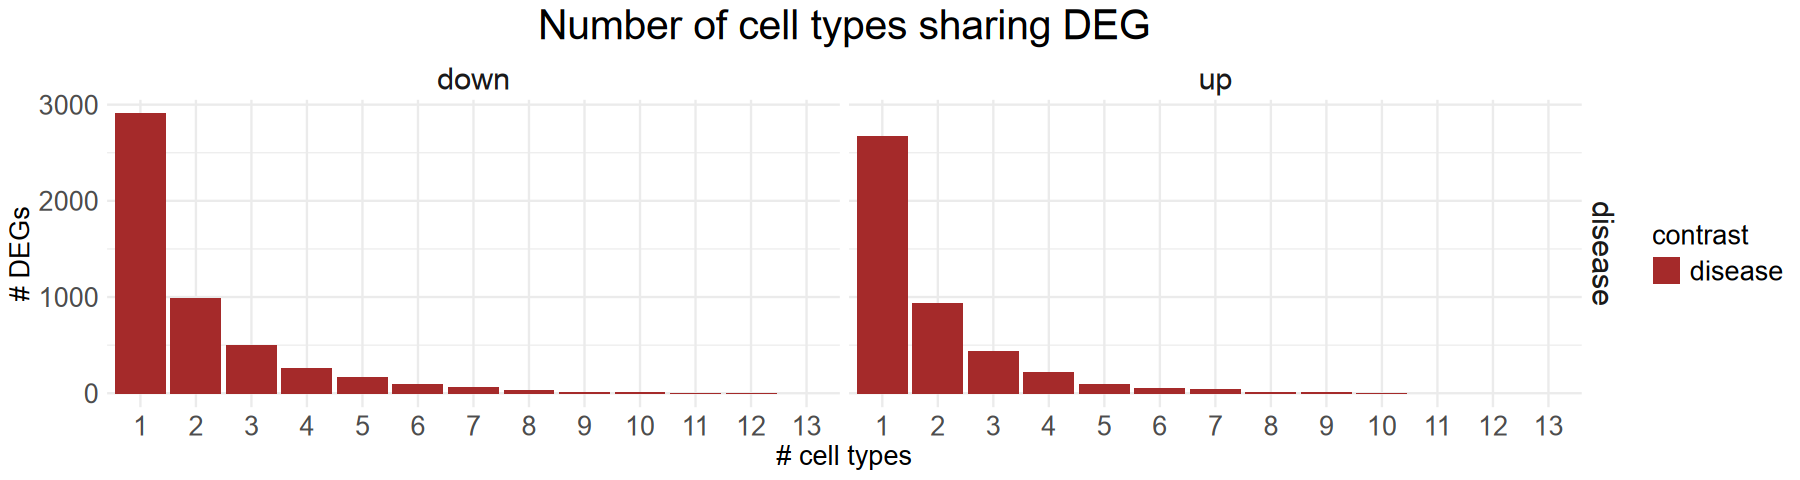

In [31]:
options(repr.plot.width = 15, repr.plot.height = 4)

p3 <- ggplot(data = combined_all_DEGs, mapping = aes(x = factor(num_cell_types), fill = contrast)) + 
  facet_grid(contrast ~ direction, scales = "free_y") + geom_bar() +  scale_x_discrete(limits = as.character(1:13)) +
  theme_minimal() + 
  theme(legend.text = element_text(size = 16), 
        legend.title = element_text(size = 16), 
        plot.title = element_text(size = 24, hjust = 0.5), 
        axis.title.x = element_text(size = 16),
        axis.title.y = element_text(size = 16),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        strip.text = element_text(size = 18)) +
  labs(title = "Number of cell types sharing DEG", 
       x = "# cell types", y = "# DEGs") +
  scale_fill_manual(values = c("brown", "gray", "#F8766D", "#619CFF"))  # Customize colors for contrast

ggsave(p3, filename = paste0(plots_dir, "04B_number_of_shared_DEGs_across_cell_types.pdf"), width = 15, height = 4)

p3